# Practice 10 — CNN Visualization

Two ways to look inside a trained network.

| View | Question it answers |
|:---|:---|
| Grad-CAM | Which region of the image supports the predicted class? |
| Feature maps | What does an early convolution respond to? |

Nothing is trained here.
The weights arrive pretrained on ImageNet.

---
## Step 0. Imports and Setup

`resnet18` arrives with ImageNet weights, and `eval()` switches batch normalization to its running
statistics.

`preprocess` is the transform those weights were fitted under.
An image scaled any other way changes the prediction before any visualization starts.

In [1]:
import urllib.request

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import models, transforms

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device)
model.eval()
imagenet_classes = models.ResNet18_Weights.DEFAULT.meta['categories']

# the statistics the pretrained weights were fitted under
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

device: cuda


---
## Step 1. A Photograph and Its Prediction

Any image works — put another link from https://unsplash.com/ in `sample_url`.

The network returns 1000 logits.
Softmax turns them into probabilities, and the five largest name what it considers most likely.

In [2]:
sample_url = ('https://images.unsplash.com/photo-1760681557777-bfac1f18cf90'
              '?ixlib=rb-4.1.0&auto=format&fit=crop&q=80&w=2070')
image_path = 'data/sample.jpg'
urllib.request.urlretrieve(sample_url, image_path)

image_tensor = preprocess(Image.open(image_path).convert('RGB')).unsqueeze(0).to(device)
print(f'input tensor: {tuple(image_tensor.shape)}')

with torch.no_grad():
    logits = model(image_tensor)
probabilities = logits.softmax(dim=1)[0].cpu().numpy()
top5_index = probabilities.argsort()[-5:][::-1]

print('Top-5 predictions')
for rank, class_index in enumerate(top5_index, start=1):
    name = imagenet_classes[class_index]
    print(f'{rank}. [{class_index:3d}] {name:<22s} {probabilities[class_index]:.4f}')

input tensor: (1, 3, 224, 224)
Top-5 predictions
1. [532] dining table           0.5120
2. [762] restaurant             0.0747
3. [799] sliding door           0.0457
4. [846] table lamp             0.0443
5. [526] desk                   0.0265


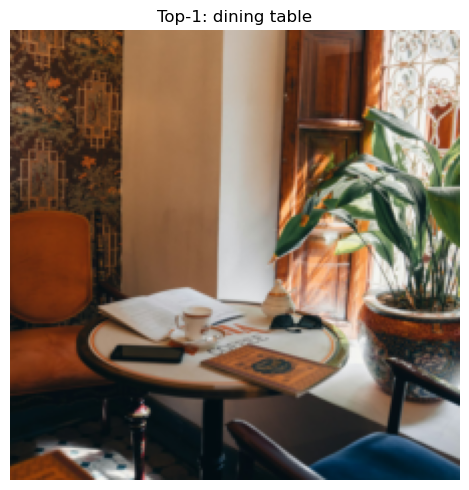

In [3]:
# turns the normalized (C, H, W) tensor back into an (H, W, C) array that imshow can display
image_rgb = image_tensor[0].permute(1, 2, 0).cpu().numpy()
image_rgb = image_rgb * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
image_rgb = np.clip(image_rgb, 0, 1).astype(np.float32)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(image_rgb)
ax.set_title(f'Top-1: {imagenet_classes[top5_index[0]]}')
ax.axis('off')
plt.tight_layout(); plt.show()

---
## Step 2. The Target Layer

Grad-CAM reads the output of one module, and that choice sets what the map can show.

`layer4[-1]` is the last residual block, whose 7x7 output carries class-specific meaning.
Earlier blocks give a finer grid but hold features that are shared across classes.

In [4]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [5]:
target_layer = model.layer4[-1]
print(target_layer)

BasicBlock(
  (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)


---
## Step 3. Grad-CAM

Let $A^k$ be channel $k$ of the target layer's output and $y^c$ the logit of class $c$.

$$\alpha^c_k = \frac{1}{Z}\sum_{i}\sum_{j}\frac{\partial y^c}{\partial A^k_{ij}},
\qquad
L^c = \mathrm{ReLU}\left(\sum_k \alpha^c_k A^k\right)$$

| Term | Meaning |
|:---|:---|
| $\partial y^c / \partial A^k_{ij}$ | how much position $(i,j)$ of channel $k$ raises the class score |
| $\alpha^c_k$ | that gradient averaged over the map, one weight per channel |
| $\mathrm{ReLU}$ | keeps what supports the class and drops what argues against it |

`pip install grad-cam` provides the implementation used below.

class [532] dining table


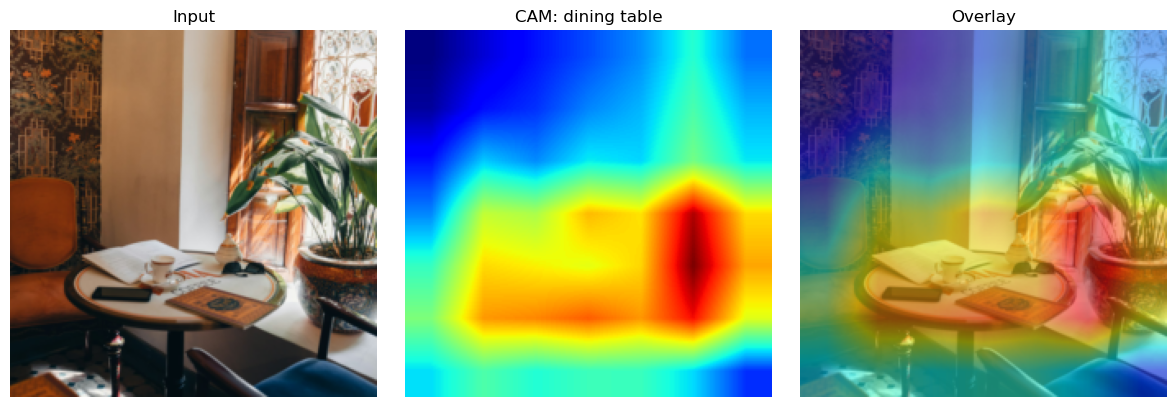

In [6]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

class_index = top5_index[0]
print(f'class [{class_index:3d}] {imagenet_classes[class_index]}')

grad_cam = GradCAM(model=model, target_layers=[target_layer])
grayscale_cam = grad_cam(input_tensor=image_tensor,
                         targets=[ClassifierOutputTarget(class_index)])[0]
overlay = show_cam_on_image(image_rgb, grayscale_cam, use_rgb=True)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image_rgb)
axes[0].set_title('Input')
axes[1].imshow(grayscale_cam, cmap='jet')
axes[1].set_title(f'CAM: {imagenet_classes[class_index]}')
axes[2].imshow(overlay)
axes[2].set_title('Overlay')
for ax in axes:
    ax.axis('off')
plt.tight_layout(); plt.show()

---
## Step 4. Feature Maps

A forward hook copies a module's output as the forward pass runs through it.
No gradient is taken, so this shows what a layer responds to rather than what supports a decision.

`conv1` returns 64 channels at 112x112, each one the photograph filtered by a different 7x7 kernel.

conv1 output: (64, 112, 112)


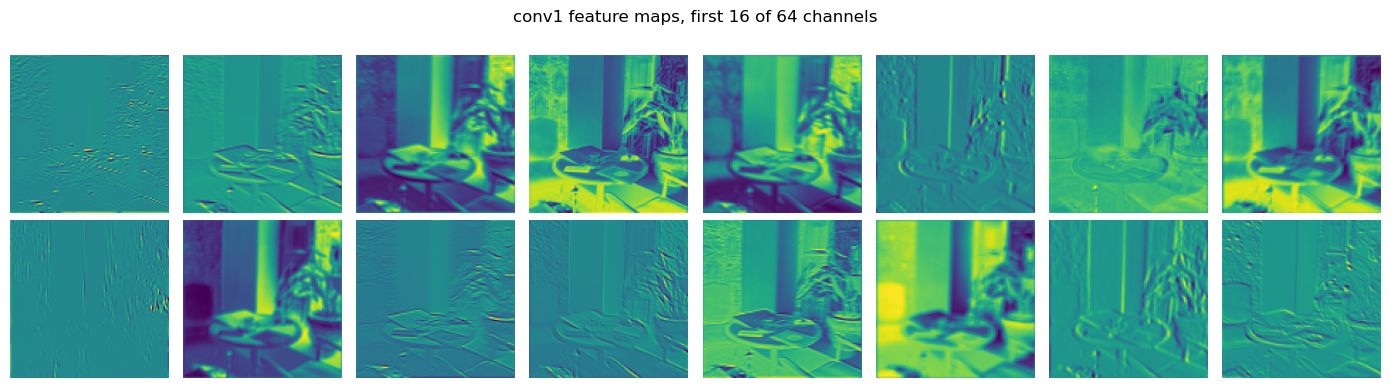

In [7]:
activations = []
hook = model.conv1.register_forward_hook(
    lambda module, inputs, output: activations.append(output.detach().cpu()))
with torch.no_grad():
    model(image_tensor)
hook.remove()

feature_maps = activations[0][0]
print(f'conv1 output: {tuple(feature_maps.shape)}')

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    channel = feature_maps[i]
    channel_range = channel.max() - channel.min()
    if channel_range == 0:
        channel_range = 1.0        # a flat channel is left as it is
    ax.imshow((channel - channel.min()) / channel_range, cmap='viridis')
    ax.axis('off')
fig.suptitle('conv1 feature maps, first 16 of 64 channels')
plt.tight_layout(); plt.show()

---
## Exercises

1. Point `class_index` at another entry of `top5_index` and rerun Step 3.
   Does the heat move with the class?
2. Set `target_layer` to `model.layer3[-1]`.
   The grid gets finer, but does the heat stay on the object?
3. Hook `model.layer4` instead of `conv1`.
   What is left of the photograph at that depth?

In [8]:
# Write your code here